In [61]:
# ================================
# Core Libraries
# ================================
import pandas as pd
import numpy as np
# ================================
# Visualization Libraries
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Machine Learning Libraries
# ================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

# ================================
# Time Series
# ================================
from statsmodels.tsa.arima.model import ARIMA

# ================================
# Settings
# ================================
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")


In [62]:
# Load LA Crime dataset
df = pd.read_csv("C:\\Users\\shrey\\Desktop\\crime_dataset\\Crime_Data_from_2020_to_Present.csv")

# View basic structure
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,31,M,H,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,32,M,H,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,30,M,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,47,F,A,101.0,STREET,NaN,NaN,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,63,M,H,103.0,ALLEY,NaN,NaN,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [63]:
# Dataset shape
print("Rows & Columns:", df.shape)

# Data types
df.info()

# Missing values
df.isnull().sum()


Rows & Columns: (1004991, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004991 non-null  int64  
 1   Date Rptd       1004991 non-null  object 
 2   DATE OCC        1004991 non-null  object 
 3   TIME OCC        1004991 non-null  int64  
 4   AREA            1004991 non-null  int64  
 5   AREA NAME       1004991 non-null  object 
 6   Rpt Dist No     1004991 non-null  int64  
 7   Part 1-2        1004991 non-null  int64  
 8   Crm Cd          1004991 non-null  int64  
 9   Crm Cd Desc     1004991 non-null  object 
 10  Mocodes         853372 non-null   object 
 11  Vict Age        1004991 non-null  int64  
 12  Vict Sex        860347 non-null   object 
 13  Vict Descent    860335 non-null   object 
 14  Premis Cd       1004975 non-null  float64
 15  Premis Desc     1004403 non-null  object 
 16  Weapon

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151619
Vict Age                0
Vict Sex           144644
Vict Descent       144656
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677744
Weapon Desc        677744
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935831
Crm Cd 3          1002677
Crm Cd 4          1004927
LOCATION                0
Cross Street       850755
LAT                     0
LON                     0
dtype: int64

In [64]:
# Convert date columns to datetime
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
df["Date Rptd"] = pd.to_datetime(df["Date Rptd"], errors="coerce")

# Drop rows where target is missing
df = df.dropna(subset=["Crm Cd"])

df["Vict Age"] = df["Vict Age"].fillna(df["Vict Age"].median())

df = df.fillna("Unknown")


C:\Users\shrey\AppData\Local\Temp\ipykernel_7088\1112132094.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
C:\Users\shrey\AppData\Local\Temp\ipykernel_7088\1112132094.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date Rptd"] = pd.to_datetime(df["Date Rptd"], errors="coerce")


In [127]:
df["DATE OCC"].head()

0   2020-11-07
1   2020-10-18
2   2020-10-30
3   2020-12-24
4   2020-09-29
Name: DATE OCC, dtype: datetime64[ns]

In [65]:
# Extract temporal features
df["Year"] = df["DATE OCC"].dt.year
df["Month"] = df["DATE OCC"].dt.month
df["Hour"] = df["TIME OCC"] // 100

# Weekend flag
df["Is_Weekend"] = df["DATE OCC"].dt.weekday >= 5

# Weapon usage flag
df["Weapon_Used"] = np.where(df["Weapon Used Cd"] == "Unknown", 0, 1)


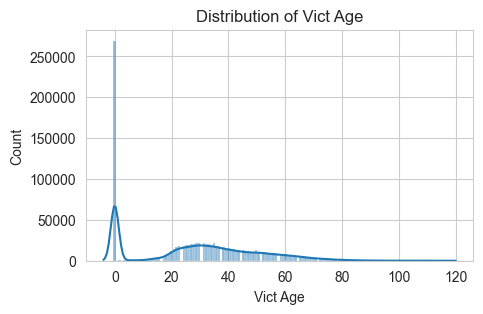

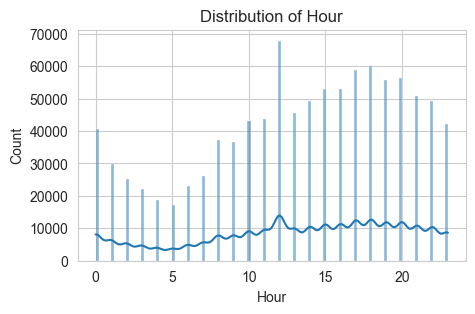

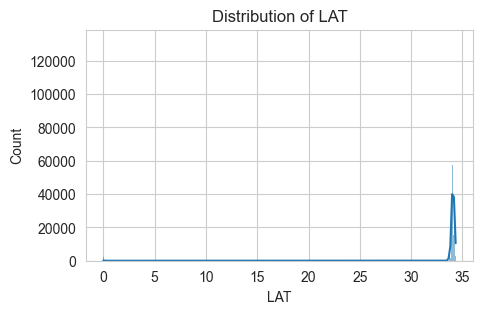

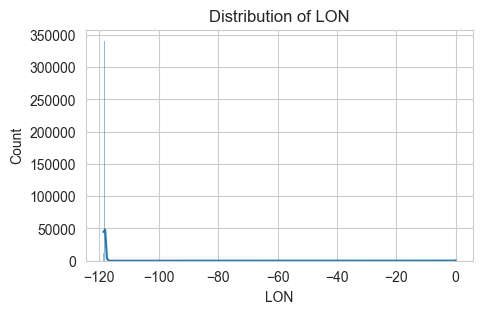

In [66]:
numeric_cols = ["Vict Age", "Hour", "LAT", "LON"]

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [67]:
#Detect Outliers
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

outliers

Vict Age        1
Hour            0
LAT         30962
LON          2269
dtype: int64

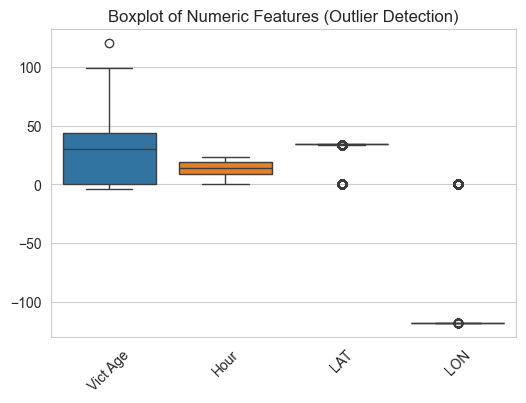

In [68]:
#Showing Outliers using Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numeric Features (Outlier Detection)")
plt.xticks(rotation=45)
plt.show()

In [69]:
# Removing Otliers
for col in numeric_cols:
    df[col] = np.where(
        df[col] < lower_bound[col],
        lower_bound[col],
        np.where(df[col] > upper_bound[col],
                 upper_bound[col],
                 df[col])
    )


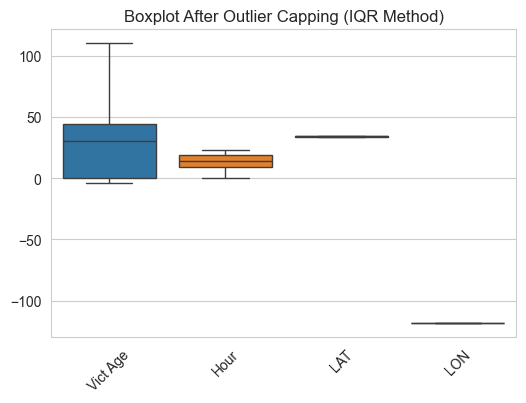

In [70]:
#Boxplot Visualisation after removing outliers
plt.figure(figsize=(6, 4))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot After Outlier Capping (IQR Method)")
plt.xticks(rotation=45)
plt.show()


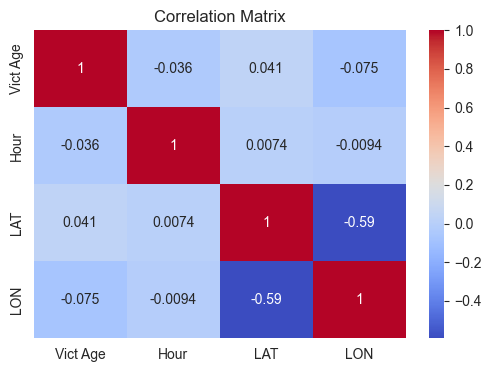

In [71]:
#Corelation
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [72]:
#Checking multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[numeric_cols]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(len(X_vif.columns))]

vif_data

,Feature,VIF
0,Vict Age,2.734314
1,Hour,5.131163
2,LAT,131318.475440
3,LON,131294.536760


In [73]:
# Handelling Collinearity
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df[numeric_cols])

In [74]:
#Encoding 
le = LabelEncoder()
df["Crime_Target"] = le.fit_transform(df["Crm Cd"])


In [75]:
#Scaling 
features = ["Vict Age", "Hour", "LAT", "LON", "Weapon_Used", "Is_Weekend"]
X = df[features]
y = df["Crime_Target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
)

In [77]:
#Supervised Learning (3 Algorithms used)
# Predict Hour of Crime using victim & location features
# Multiple Linear Regression (OLS)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_reg = df[["Vict Age", "LAT", "LON", "Is_Weekend"]]
y_reg = df["Hour"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 5.427062005709312


In [78]:
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 42.303613057131734


In [79]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE: 6.504122773835972


In [80]:
print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.0017374096672179151


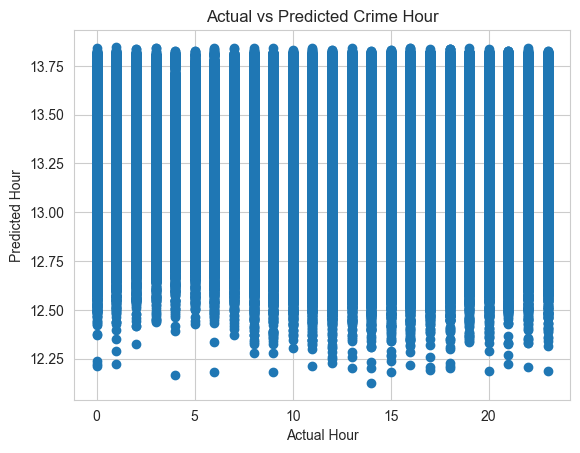

In [81]:
#Visualisation of objective 1
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Hour")
plt.ylabel("Predicted Hour")
plt.title("Actual vs Predicted Crime Hour")
plt.show()

In [82]:
# Crime Type prediction using KNN 
from sklearn.neighbors import KNeighborsClassifier

X = X_scaled
y = df["Crime_Target"]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print(classification_report(y_test, knn_pred))


              precision    recall  f1-score   support

         0.0       0.05      0.17      0.08      8084
         1.0       0.04      0.11      0.06      5966
         2.0       0.03      0.08      0.05      5069
         3.0       0.03      0.07      0.04      4410
         4.0       0.02      0.04      0.03      3749
         5.0       0.03      0.04      0.03      3517
         6.0       0.03      0.06      0.04      4559
         7.0       0.04      0.06      0.05      5240
         8.0       0.05      0.06      0.06      7534
         9.0       0.05      0.06      0.05      7306
        10.0       0.05      0.05      0.05      8787
        11.0       0.06      0.05      0.05      8733
        12.0       0.08      0.07      0.08     13483
        13.0       0.05      0.03      0.04      8949
        14.0       0.06      0.04      0.05      9843
        15.0       0.07      0.04      0.05     10630
        16.0       0.06      0.03      0.04     10642
        17.0       0.07    

In [83]:
# confusion matrix
print(confusion_matrix(y_test, knn_pred))

[[1401  729  487  412  280  246  301  324  365  335  321  312  432  186
   239  203  179  206  232  209  208  162  168  147]
 [ 885  684  425  279  245  185  230  218  263  222  253  182  278  157
   140  147  136  173  166  137  158  135  137  131]
 [ 771  529  403  260  185  162  198  171  217  212  190  168  272  115
   137  142   99  135  137  123  132  103  114   94]
 [ 621  417  309  289  182  115  151  186  219  180  159  146  226   86
   133  125  117  113  130  102  122  116   95   71]
 [ 523  377  269  210  168  127  141  141  186  128  136  127  206   73
   101  100   72  107  101   86   97  108   92   73]
 [ 483  331  246  200  162  158  143  117  141  136  154  126  199   85
    91   81   82  106  109   92   81   71   68   55]
 [ 653  391  273  222  174  147  256  252  229  180  211  151  241  113
   138  113  104  128  120  100  114   96   94   59]
 [ 656  456  306  259  183  156  236  333  269  233  241  192  297  146
   150  169  120  144  160  122  133  107  111   61]


In [84]:
#Crime Type Prediction Using Decision tree to visualise top 5 crime type
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [85]:
dt_pred = dt.predict(X_test)
dt_pred

array([12., 12., 12., ..., 20., 18., 12.], shape=(200999,))

In [86]:
# Convert predictions to integer
dt_pred_int = dt_pred.astype(int)

# Decode to original crime codes
dt_pred_labels = le.inverse_transform(dt_pred_int)

In [87]:
# Create mapping from Crime Code to Crime Description
crime_code_to_name = (
    df[["Crm Cd", "Crm Cd Desc"]]
    .drop_duplicates()
    .set_index("Crm Cd")["Crm Cd Desc"]
    .to_dict()
)

In [88]:
dt_pred_names = [crime_code_to_name.get(code, "Unknown") for code in dt_pred_labels]

In [89]:
top_5_dt_crimes_named = (
    pd.Series(dt_pred_names)
    .value_counts()
    .head(5)
)

print(top_5_dt_crimes_named)

SHOTS FIRED AT INHABITED DWELLING           133415
SHOPLIFTING-GRAND THEFT ($950.01 & OVER)     37872
GRAND THEFT / INSURANCE FRAUD                10223
CRIMINAL HOMICIDE                            10168
DISHONEST EMPLOYEE - GRAND THEFT              3021
Name: count, dtype: int64


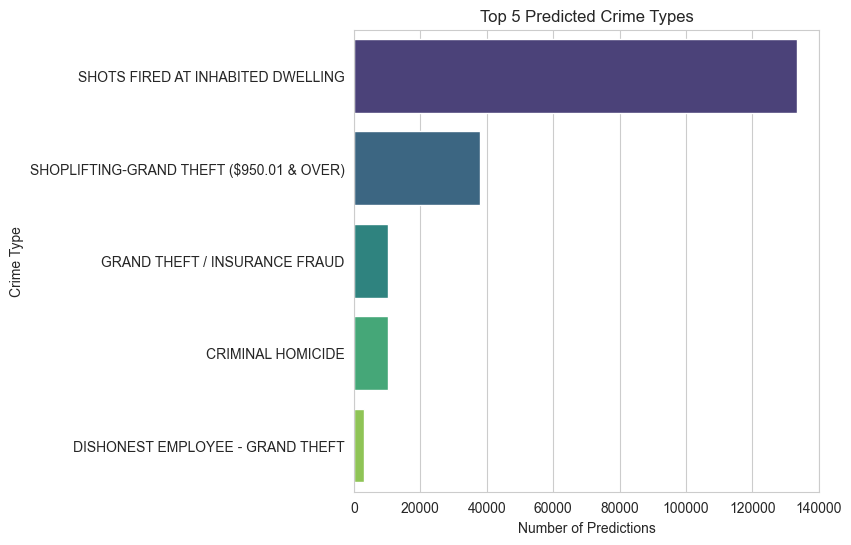

In [126]:
# Visualisation of top 5 crime type
plt.figure(figsize=(6,6))
sns.barplot(
    x=top_5_dt_crimes_named.values,
    y=top_5_dt_crimes_named.index,
    hue=top_5_dt_crimes_named.index,
    palette="viridis",
    legend = False
)
plt.title("Top 5 Predicted Crime Types")
plt.xlabel("Number of Predictions") 
plt.ylabel("Crime Type")
plt.show()


In [91]:
# Crime Count Prediction (Using Linear Regression)
# Create Year-Month column
df["YearMonth"] = df["DATE OCC"].dt.to_period("M")

# Aggregate crime counts per month
crime_monthly = (
    df.groupby("YearMonth")
      .size()
      .reset_index(name="Crime_Count")
)

crime_monthly["YearMonth"] = crime_monthly["YearMonth"].astype(str)
crime_monthly.head()

,YearMonth,Crime_Count
0,2020-01,18576
1,2020-02,17284
2,2020-03,16188
3,2020-04,15706
4,2020-05,17230


In [92]:
# Convert YearMonth to numeric index
crime_monthly["Time_Index"] = range(len(crime_monthly))

X = crime_monthly[["Time_Index"]]
y = crime_monthly["Crime_Count"]

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [94]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [95]:
y_pred = lr.predict(X_test)
y_pred

array([19454.46832579, 19504.35682575, 19554.24532571, 19604.13382566,
       19654.02232562, 19703.91082558, 19753.79932554, 19803.68782549,
       19853.57632545, 19903.46482541, 19953.35332536, 20003.24182532,
       20053.13032528])

In [96]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 14976.491633228037
MSE : 240836696.180093
RMSE: 15518.914143073702
R²  : -14.875043050282912


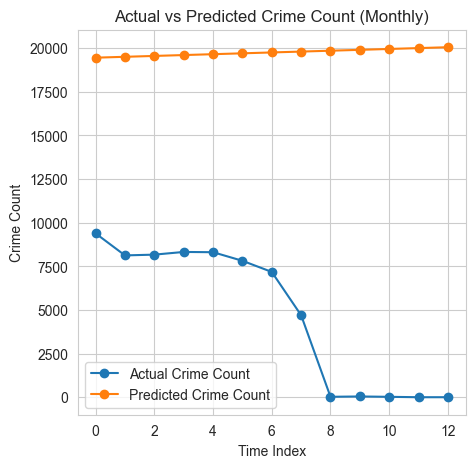

In [97]:
#Visualisation of Actual and Predicted Crime Count
plt.figure(figsize=(5,5))
plt.plot(y_test.values, label="Actual Crime Count", marker="o")
plt.plot(y_pred, label="Predicted Crime Count", marker="o")
plt.title("Actual vs Predicted Crime Count (Monthly)")
plt.xlabel("Time Index")
plt.ylabel("Crime Count")
plt.legend()
plt.show()

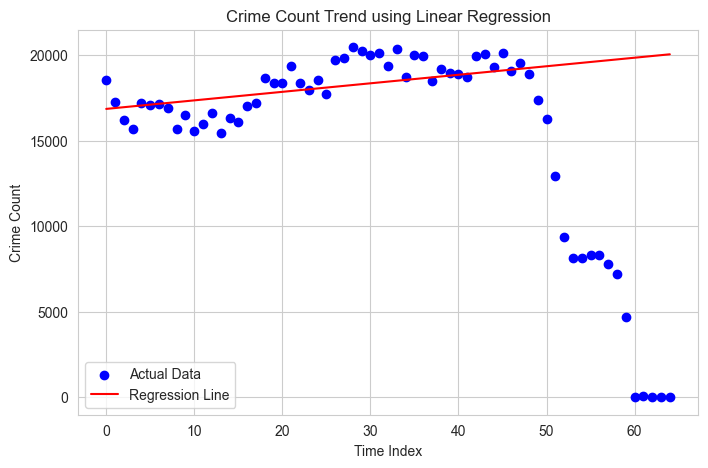

In [98]:
# Crime Count Trend using Linear Regression to predict future crime trends
plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, lr.predict(X), color="red", label="Regression Line")
plt.title("Crime Count Trend using Linear Regression")
plt.xlabel("Time Index")
plt.ylabel("Crime Count")
plt.legend()
plt.show()

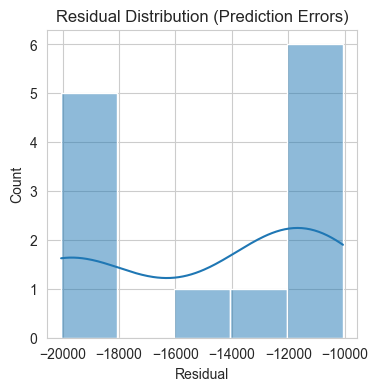

In [99]:
# Residual Graph to show prediction error distribution
residuals = y_test - y_pred

plt.figure(figsize=(4,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Prediction Errors)")
plt.xlabel("Residual")
plt.show()

In [100]:
# CRIME SEVERITY CLASSIFICATION Using Decision Tree and visualisation of it
# Assign Crime Severity
# ----------------
def assign_severity(crime_desc):
    crime_desc = str(crime_desc).lower()
    if any(word in crime_desc for word in ["murder", "homicide", "rape", "assault", "robbery"]):
        return "High"
    elif any(word in crime_desc for word in ["burglary", "theft", "vehicle", "stolen"]):
        return "Medium"
    else:
        return "Low"

df["Crime_Severity"] = df["Crm Cd Desc"].apply(assign_severity)



In [101]:
# ----------------
# Encode Target Variable
# ----------------
severity_encoder = LabelEncoder()
df["Severity_Target"] = severity_encoder.fit_transform(df["Crime_Severity"])

In [102]:
# ----------------
# Feature Selection
# ----------------
features = ["Vict Age", "Hour", "LAT", "LON", "Weapon_Used", "Is_Weekend"]
X = df[features]
y = df["Severity_Target"]

In [103]:
# ----------------
# Scaling
# ----------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------
# Train-Test Split
# ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [104]:
# ----------------
# Train Decision Tree Model
# ----------------
dt_severity = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_severity.fit(X_train, y_train)

# ----------------
# Prediction
# ----------------
severity_pred = dt_severity.predict(X_test)


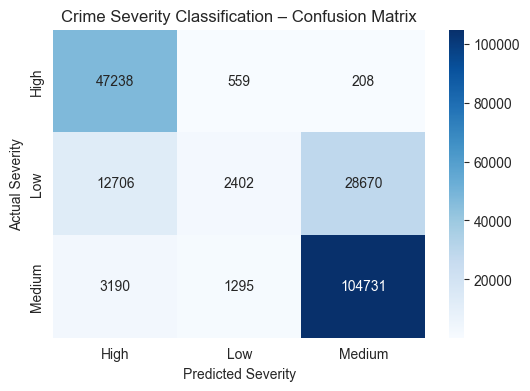

In [105]:
# ----------------
# Confusion Matrix Visualization
# ----------------
cm = confusion_matrix(y_test, severity_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=severity_encoder.classes_,
    yticklabels=severity_encoder.classes_
)
plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.title("Crime Severity Classification – Confusion Matrix")
plt.show()



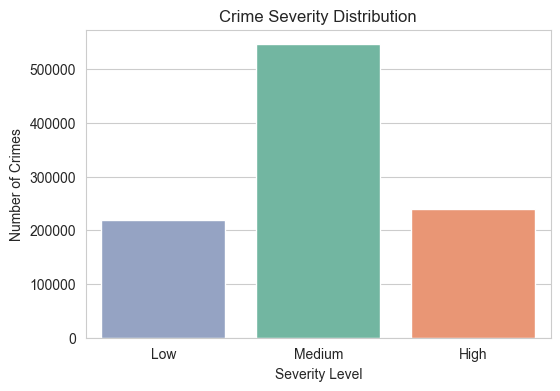

In [123]:
# ----------------
# Severity Distribution Visualization
# ----------------
plt.figure(figsize=(6,4))
sns.countplot(
    x="Crime_Severity",
    data=df,
    order=["Low", "Medium", "High"],
    palette="Set2",
    hue="Crime_Severity",
    legend = False
)
plt.title("Crime Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Crimes")
plt.show()


In [107]:
# ----------------
# Classification Report
# ----------------
print(
    classification_report(
        y_test,
        severity_pred,
        target_names=severity_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.75      0.98      0.85     48005
         Low       0.56      0.05      0.10     43778
      Medium       0.78      0.96      0.86    109216

    accuracy                           0.77    200999
   macro avg       0.70      0.67      0.60    200999
weighted avg       0.73      0.77      0.69    200999



In [120]:
# Predict Weapon Used (Yes/No) using Naive Bayes
from sklearn.naive_bayes import GaussianNB

X_nb = df[["Hour", "Vict Age"]]
y_nb = df["Weapon_Used"]

X_train, X_test, y_train, y_test = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42
)

nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print(classification_report(y_test, nb_pred, zero_division=0))
# zero division is used to remove the warning 

              precision    recall  f1-score   support

           0       0.67      1.00      0.81    135655
           1       0.00      0.00      0.00     65344

    accuracy                           0.67    200999
   macro avg       0.34      0.50      0.40    200999
weighted avg       0.46      0.67      0.54    200999



In [109]:
# Unsupervised Algorithms 

Silhouette Score (sampled): 0.22192570158755334


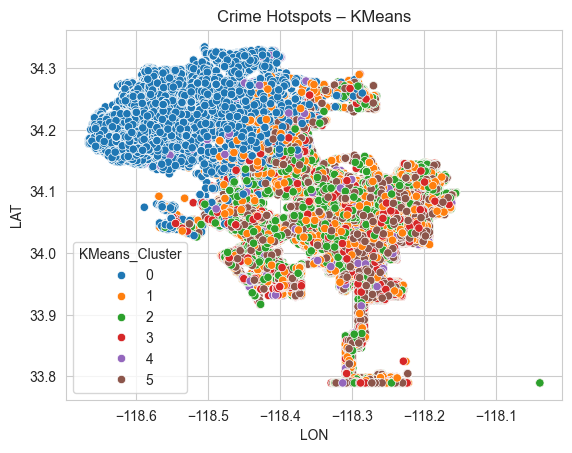

In [110]:
# Crime Clustering by Geographic Patterns to Identify Crime Hotspots using KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=6, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(
    X_scaled,
    df["KMeans_Cluster"],
    sample_size=10000,      # safe & fast
    random_state=42
)

print("Silhouette Score (sampled):", sil_score)

sns.scatterplot(
    x=df["LON"], y=df["LAT"],
    hue=df["KMeans_Cluster"],
    palette="tab10"
)
plt.title("Crime Hotspots – KMeans")
plt.show()

In [111]:
# Detection of dominant time windows on the basis of crime occurrence 
# Using Frequency-Based Pattern Mining (An unsupervised Learning Algorithm)
# -------------------------------
# Prepare Time Features
# -------------------------------
df["Hour"] = df["TIME OCC"] // 100
df["Day"] = df["DATE OCC"].dt.day_name()

# Order days properly
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

In [112]:
# -------------------------------
# Create Hour x Day Frequency Table
# -------------------------------
time_day_matrix = pd.crosstab(
    df["Hour"],
    df["Day"]
).reindex(columns=day_order)


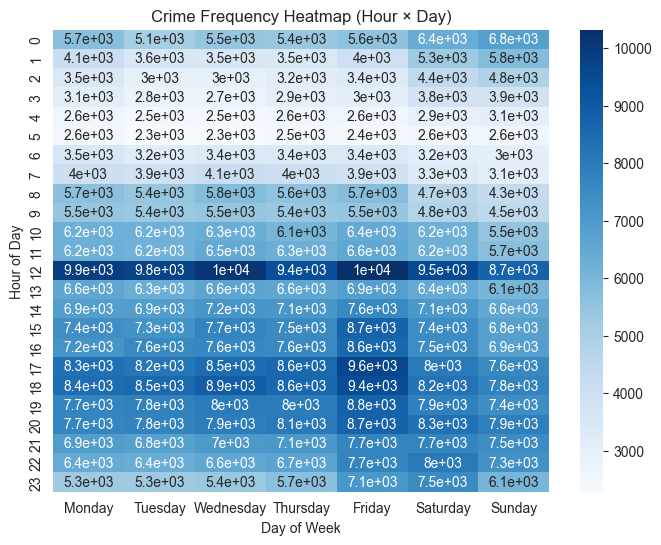

In [113]:
# -------------------------------
# Heatmap Visualization
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(
    time_day_matrix,
    cmap="Blues",
    annot = True
)
plt.title("Crime Frequency Heatmap (Hour × Day)")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.show()


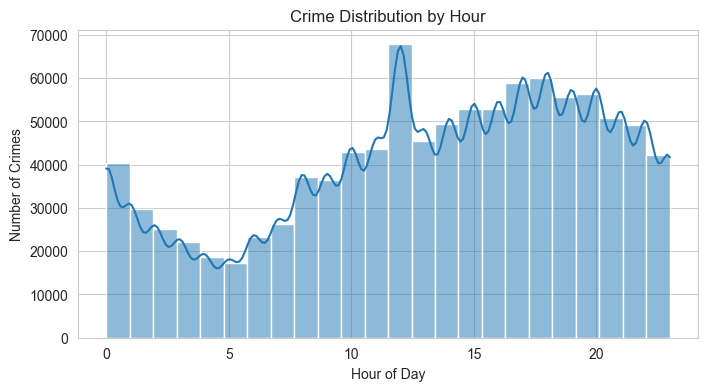

In [114]:
# -------------------------------
# Distribution Plot: Crimes by Hour
# -------------------------------
plt.figure(figsize=(8,4))
sns.histplot(
    df["Hour"],
    bins=24,
    kde=True
)
plt.title("Crime Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.show()


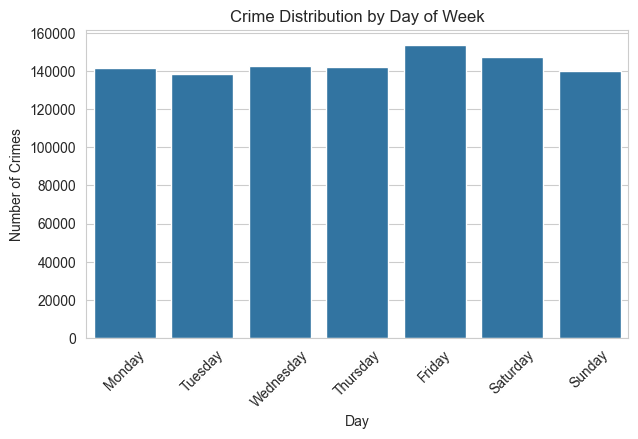

In [115]:
# -------------------------------
# Distribution Plot: Crimes by Day
# -------------------------------
plt.figure(figsize=(7,4))
sns.countplot(
    x="Day",
    data=df,
    order=day_order
)
plt.title("Crime Distribution by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.show()

In [116]:
# Analyse the Crime Pattern and its hierarchy and its Visualisation using dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Use numeric behavioral features
X_hier = df[["Vict Age", "Hour"]]

# Scaling is important for distance-based methods
scaler = StandardScaler()
X_hier_scaled = scaler.fit_transform(X_hier)

In [117]:
# Use a sample to avoid heavy computation
linked = linkage(
    X_hier_scaled[:1000],   # sampling for performance
    method="ward"           # minimizes variance
)

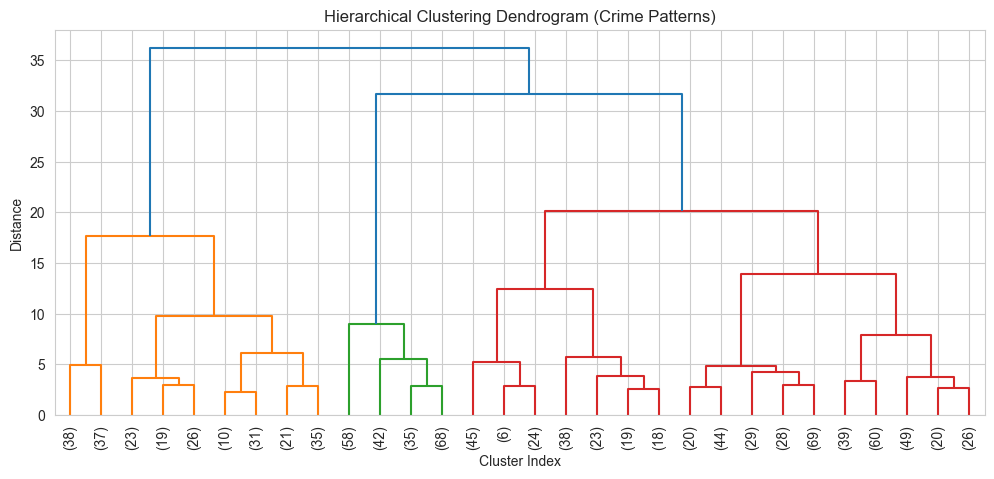

In [118]:
plt.figure(figsize=(12,5))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram (Crime Patterns)")
plt.xlabel("Cluster Index")
plt.ylabel("Distance")
plt.show()


In [119]:
# Find relationship between crime type, weapon used, time category using association rule (Pattern Minning)
from mlxtend.frequent_patterns import apriori, association_rules

basket = pd.get_dummies(
    df[["Weapon_Used", "Is_Weekend"]].astype(str)
)

freq_items = apriori(basket, min_support=0.05, use_colnames=True)

rules = association_rules(freq_items, metric="confidence", min_threshold=0.6)
rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Is_Weekend_False),(Weapon_Used_0),0.714319,0.674378,0.489793,0.685679,1.016757,1.0,0.008072,1.035953,0.057691,0.544879,0.034705,0.705984
1,(Weapon_Used_0),(Is_Weekend_False),0.674378,0.714319,0.489793,0.726289,1.016757,1.0,0.008072,1.043733,0.050615,0.544879,0.041900,0.705984
2,(Is_Weekend_True),(Weapon_Used_0),0.285681,0.674378,0.184585,0.646121,0.958100,1.0,-0.008072,0.920151,-0.057691,0.238028,-0.086778,0.459916
3,(Weapon_Used_1),(Is_Weekend_False),0.325622,0.714319,0.224525,0.689528,0.965295,1.0,-0.008072,0.920151,-0.050615,0.275351,-0.086778,0.501925
